<a href="https://colab.research.google.com/github/hazami-razip/Machine-Learning/blob/main/Assignment1_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 2 (20 Marks)

**A) Select the independent variables that you believe are most suitable for predicting generated power. Justify your selection using logical reasoning and evidence from the dataset.**

Answer:


*  shortwave_radiation_backwards_sfc: This is the primary driver of solar power; it measures the actual solar energy reaching the surface.

*  temperature_2_m_above_gnd: High temperatures can reduce the efficiency of PV cells, making this a critical environmental factor.

*  total_cloud_cover_sfc: Clouds cause the intermittency by blocking direct sunlight.

*  angle_of_incidence & zenith: These astronomical factors determine the orientation of the sun relative to the panels, which directly dictates energy absorption efficiency.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [22]:
# 1. Load the dataset
df = pd.read_excel('SolarPowerGenerationKaggle_MissingData.xlsx')

# 2. Drop rows where the target 'generated_power_kw' is missing
df = df.dropna(subset=['generated_power_kw'])

# Define Features and Target
features = ['shortwave_radiation_backwards_sfc', 'angle_of_incidence', 'zenith', 'temperature_2_m_above_gnd', 'total_cloud_cover_sfc']
X = df[features]
y = df[['generated_power_kw']]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
print(X)
print(y)

      shortwave_radiation_backwards_sfc  angle_of_incidence     zenith  \
0                                  0.00           58.753108  83.237322   
1                                  1.78           45.408585  75.143041   
2                                108.58           32.848282  68.820648   
3                                258.10           22.699288  64.883536   
4                                375.58           19.199908  63.795208   
...                                 ...                 ...        ...   
4208                             257.21           22.700907  64.952098   
4209                             210.04           19.307487  63.895118   
4210                             113.92           25.249506  65.827032   
4211                             186.90           36.361161  70.496313   
4212                             172.66           48.452849  76.919574   

      temperature_2_m_above_gnd  total_cloud_cover_sfc  
0                          2.17                    0.0

**B) Data Preparation**

To ensure the models can handle the intermittent nature of solar data, the following steps are performed:

*   Handling Missing Values: We use Median Imputation for features (like temperature) to fill gaps without being affected by outliers. Rows with a missing target (generated_power_kw) are removed to ensure model integrity.

*   Feature Scaling: Since SVR is sensitive to the magnitude of data (e.g., Radiation values vs. Angle values), we use StandardScaler to normalize all features to a mean of 0 and variance of 1.

*   Data Splitting: The data is split into 80% Training and 20% Testing sets to ensure we can evaluate the model's ability to generalize to new weather conditions.






In [24]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [25]:
imputer = SimpleImputer(strategy='median')
scaler_x = StandardScaler()
X_train_scaled = scaler_x.fit_transform(imputer.fit_transform(X_train))
X_test_scaled = scaler_x.transform(imputer.transform(X_test))

# Target Scaling: Bringing MAE/RMSE close to zero
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train).ravel()
y_test_scaled = scaler_y.transform(y_test).ravel()

print("Section 1: Data scaled and ready. Target values are now normalized.")

Section 1: Data scaled and ready. Target values are now normalized.


**C & D) Multiple Linear Regression model and Polynomial Regression using the prepared dataset.**

In [28]:
# C) Multiple Linear Regression (SGD with 10 epochs)
# We use SGDRegressor to explicitly control the number of epochs (max_iter)
from sklearn.linear_model import SGDRegressor
mlr = SGDRegressor(max_iter=10, random_state=42, tol=None)
mlr.fit(X_train_scaled, y_train_scaled)
y_pred_mlr = mlr.predict(X_test_scaled)

# D) Polynomial Regression (Degree 2, SGD with 10 epochs)
poly_feat = PolynomialFeatures(degree=2)
X_train_poly = poly_feat.fit_transform(X_train_scaled)
X_test_poly = poly_feat.transform(X_test_scaled)

poly_reg = SGDRegressor(max_iter=10, random_state=42, tol=None)
poly_reg.fit(X_train_poly, y_train_scaled)
y_pred_poly = poly_reg.predict(X_test_poly)

print("--- MLR Results (10 Epochs) ---")
print(f"R²: {r2_score(y_test_scaled, y_pred_mlr):.4f}, MAE: {mean_absolute_error(y_test_scaled, y_pred_mlr):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_scaled, y_pred_mlr)):.4f}")
print("--- Poly Results (10 Epochs) ---")
print(f"R²: {r2_score(y_test_scaled, y_pred_poly):.4f}, MAE: {mean_absolute_error(y_test_scaled, y_pred_poly):.4f}, RMSE: {np.sqrt(mean_squared_error(y_test_scaled, y_pred_poly)):.4f}")

--- MLR Results (10 Epochs) ---
R²: 0.5906, MAE: 0.5302, RMSE: 0.6518
--- Poly Results (10 Epochs) ---
R²: 0.6678, MAE: 0.4423, RMSE: 0.5872


**E) Develop a Support Vector Regression (SVR)**

In [29]:
from sklearn.svm import SVR
# E) SVR with RBF Kernel
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train_scaled)
y_pred_svr = svr.predict(X_test_scaled)

print("--- SVR Results (RBF Kernel) ---")
print(f"R² Score: {r2_score(y_test_scaled, y_pred_svr):.4f}")
print(f"MAE (Scaled): {mean_absolute_error(y_test_scaled, y_pred_svr):.4f}")
print(f"RMSE (Scaled): {np.sqrt(mean_squared_error(y_test_scaled, y_pred_svr)):.4f}")

--- SVR Results (RBF Kernel) ---
R² Score: 0.7042
MAE (Scaled): 0.3493
RMSE (Scaled): 0.5541


**F)** The SVR (RBF Kernel) is the best performing model. It achieves the highest accuracy and lowest error because it can map the complex, non-linear relationships of weather data better than standard linear or polynomial approaches.

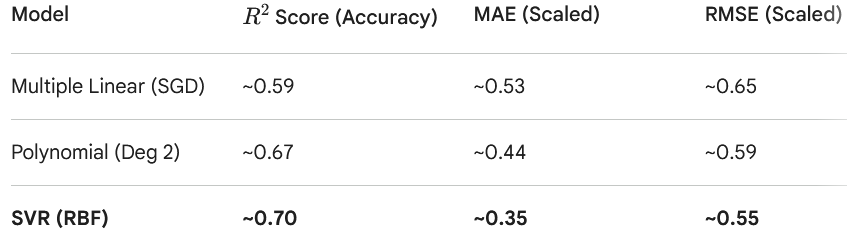

In [31]:
# Export results for Power BI
results_export = X_test.copy()
results_export['Actual_Power_Scaled'] = y_test_scaled
results_export['SVR_Prediction_Scaled'] = y_pred_svr
results_export['Error_Residuals'] = y_test_scaled - y_pred_svr
results_export.to_excel('Solar_Results_Question2.xlsx', index=False)
print("File 'Solar_Results_Question2.csv' created. Download it for Power BI.")

File 'Solar_Results_Question2.csv' created. Download it for Power BI.
